In [9]:
#lets start
import numpy as np
import pandas as pd
df=pd.read_csv("student_data.csv")

print("shape :",df.shape)
print("datatypes of columns are:",df.dtypes)
print("count of missing values of colums:",df.isnull().sum().sum())

df['pass_fail']=(df['G3']>=10).astype(int)

df=df.drop(columns=['G1','G2','G3'])

print("target distribution is :", df['pass_fail'].value_counts())



shape : (649, 33)
datatypes of columns are: school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object
count of missing values of colums: 0
target distribution is : pass_fail
1    549
0    100
Name: count, dtype: int64


In [10]:
print("first 5 rows data is :")
print(df.head(5))

first 5 rows data is :
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  internet romantic  famrel  freetime  goout Dalc Walc health absences  \
0       no       no       4         3      4    1    1      3        4   
1      yes       no       5         3      3    1    1      3        2   
2      yes       no       4         3      2    2    3      3        6   
3      yes      yes       3         2      2    1    1      5        0   
4       no       no       4         3      2    1    2      5        0   

  pass_fail  
0         1  
1         1  
2  

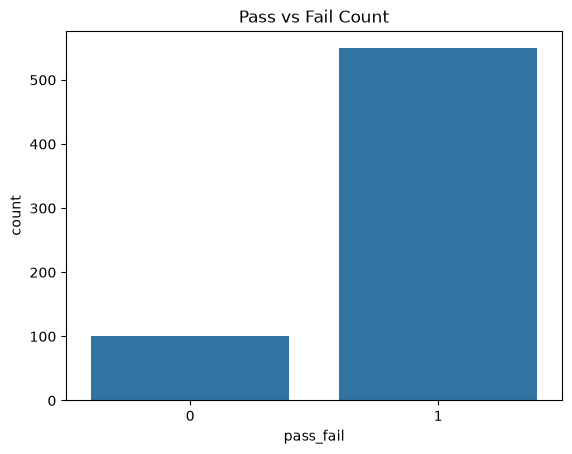

pass_fail     1.000000
studytime     0.165111
Fedu          0.146249
Medu          0.144803
famrel        0.044987
health       -0.009979
traveltime   -0.057869
goout        -0.067241
absences     -0.087483
freetime     -0.093349
age          -0.110722
Walc         -0.116249
Dalc         -0.123627
failures     -0.380237
Name: pass_fail, dtype: float64


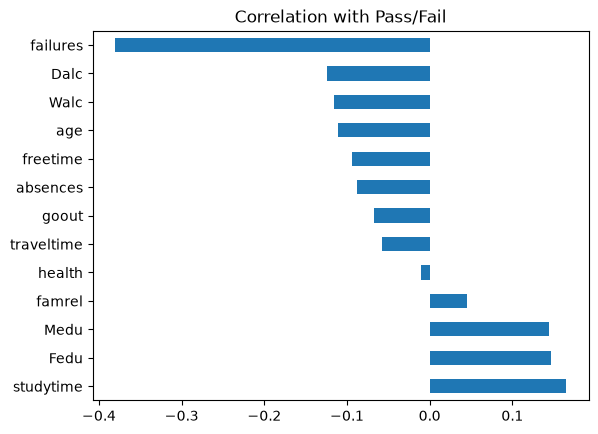

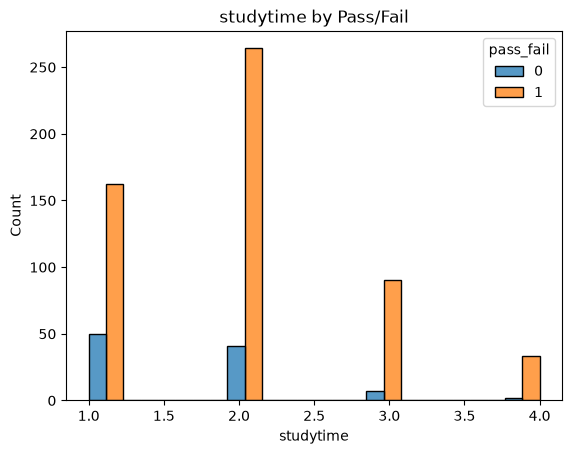

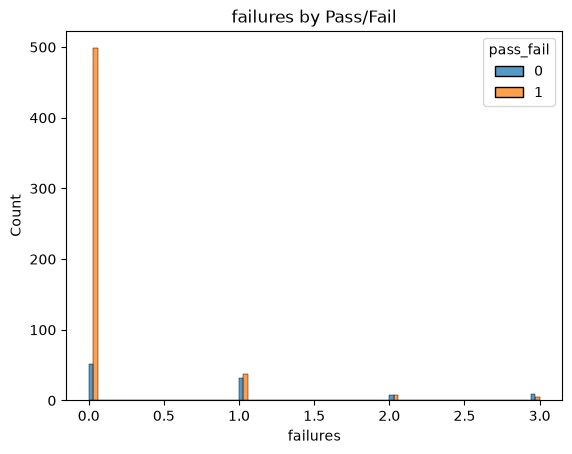

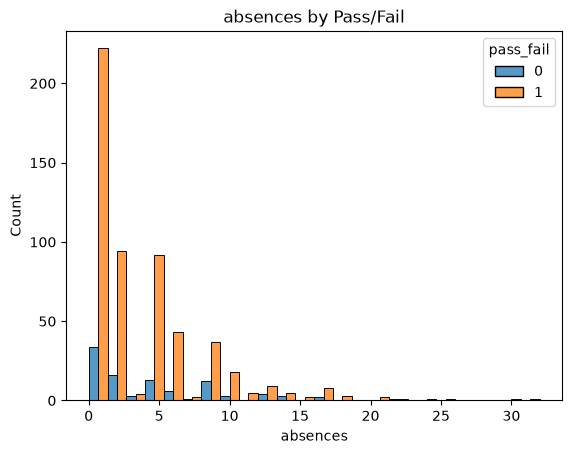

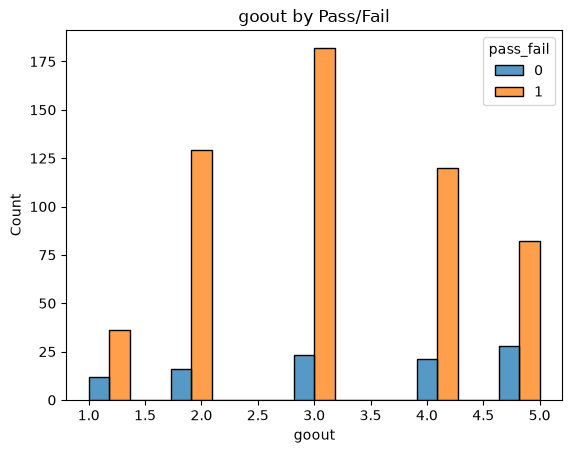

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Class balance plot
sns.countplot(x='pass_fail', data=df)
plt.title('Pass vs Fail Count')
plt.show()

# 2. Correlation of numeric features with target
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['pass_fail'].sort_values(ascending=False)
print(correlations)

correlations.drop('pass_fail').plot(kind='barh')
plt.title('Correlation with Pass/Fail')
plt.show()

# 3. Distribution of key features split by class
key_features = ['studytime', 'failures', 'absences', 'goout']

for feature in key_features:
    sns.histplot(data=df, x=feature, hue='pass_fail', multiple='dodge')
    plt.title(f'{feature} by Pass/Fail')
    plt.show()

In [12]:
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(categorical_cols)

binary_cols=[col for col in categorical_cols if df[col].nunique()==2]
multi_cols=[col for col in categorical_cols if df[col].nunique()>2]
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
 
for col in binary_cols:
    df[col]= le.fit_transform(df[col])

df=pd.get_dummies(df,columns=multi_cols,drop_first=True)



# feature engineering 


df['parent_edu_avg']=(df['Medu']+df['Fedu'])/2
print(df['parent_edu_avg'])


df['social_score'] =df['goout']+ df['Dalc']+ df['Walc']


print(df.isnull().sum().sum())
df=df.fillna(df.median(numeric_only=True))

# seperating target

X=df.drop(columns=['pass_fail'])
Y=df['pass_fail']
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled=pd.DataFrame(X_scaled,columns=X.columns)
print("Final feature shape :",X_scaled.shape)
print(X_scaled.head())

['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
0      4.0
1      1.0
2      1.0
3      3.0
4      3.0
      ... 
644    2.5
645    2.0
646    1.0
647    2.0
648    2.5
Name: parent_edu_avg, Length: 649, dtype: float64
0
Final feature shape : (649, 41)
     school       sex       age   address   famsize   Pstatus      Medu  \
0 -0.730944 -0.833377  1.031695  0.660182 -0.648175 -2.666927  1.310216   
1 -0.730944 -0.833377  0.210137  0.660182 -0.648175  0.374963 -1.336039   
2 -0.730944 -0.833377 -1.432980  0.660182  1.542792  0.374963 -1.336039   
3 -0.730944 -0.833377 -1.432980  0.660182 -0.648175  0.374963  1.310216   
4 -0.730944 -0.833377 -0.611422  0.660182 -0.648175  0.374963  0.428131   

       Fedu  traveltime  studytime  ...  Fjob_other  Fjob_services  \
0  1.540715    0.576718   0.083653  ...   -1.140797      -0.621894   
1 -1.188832   -0.760032  

In [13]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X_scaled,Y,test_size=0.2,stratify=Y,random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train class balance:\n", y_train.value_counts(normalize=True))
print("y_test class balance:\n", y_test.value_counts(normalize=True))

X_train shape: (519, 41)
X_test shape: (130, 41)
y_train class balance:
 pass_fail
1    0.845857
0    0.154143
Name: proportion, dtype: float64
y_test class balance:
 pass_fail
1    0.846154
0    0.153846
Name: proportion, dtype: float64


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_predict = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_predict),
        "Precision": precision_score(y_test, y_predict),
        "Recall": recall_score(y_test, y_predict),
        "F1-score": f1_score(y_test, y_predict),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }
    trained_models[name] = model   # save the fitted model for later stages

result_df = pd.DataFrame(results).T
print(result_df)

                     Accuracy  Precision    Recall  F1-score   ROC-AUC
Logistic Regression  0.792308   0.867257  0.890909  0.878924  0.619545
Decision Tree        0.746154   0.853211  0.845455  0.849315  0.522727
Random Forest        0.807692   0.851240  0.936364  0.891775  0.642727
Gradient Boosting    0.792308   0.867257  0.890909  0.878924  0.646818


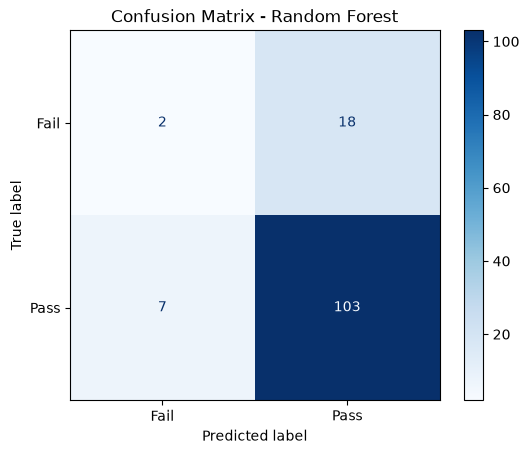

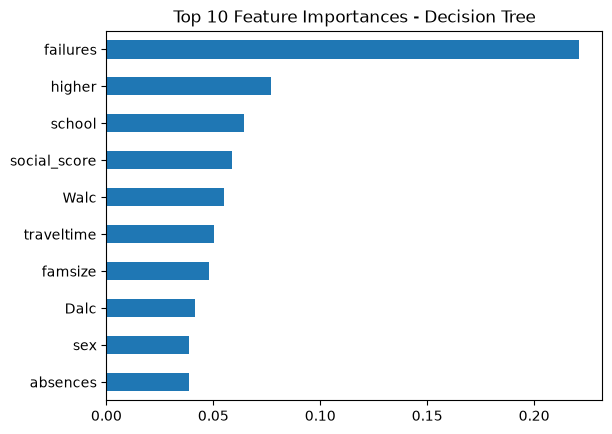

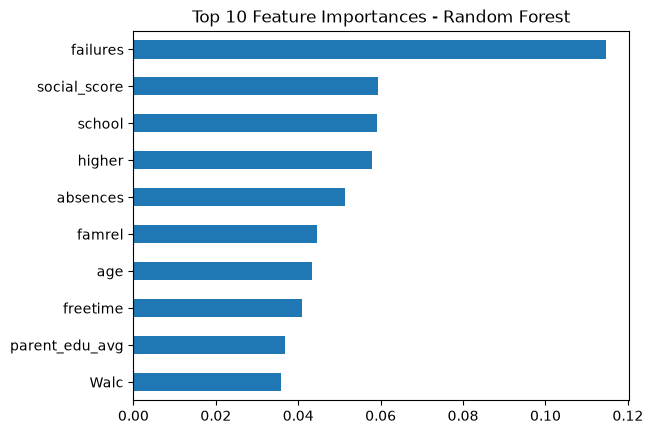

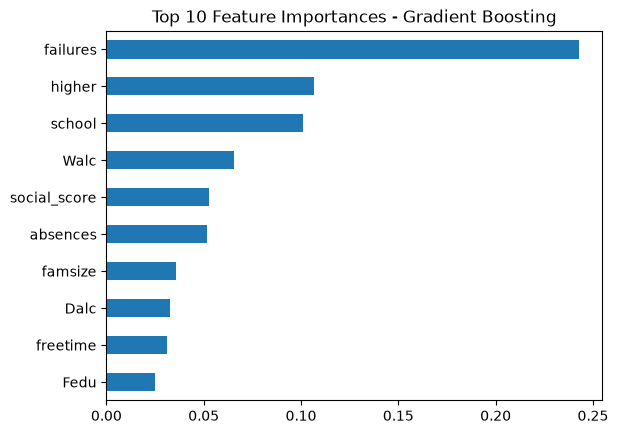

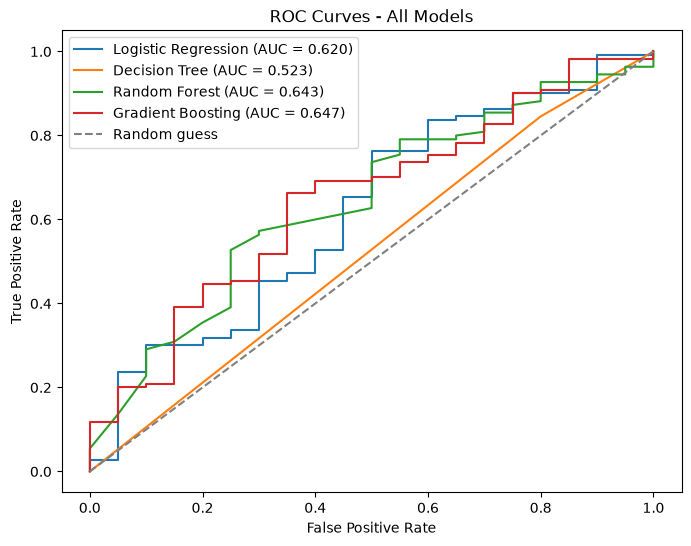

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

best_model_name = "Random Forest"
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fail", "Pass"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

tree_models = ["Decision Tree", "Random Forest", "Gradient Boosting"]

for name in tree_models:
    model = trained_models[name]
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=False).head(10)

    importances.plot(kind='barh')
    plt.title(f"Top 10 Feature Importances - {name}")
    plt.gca().invert_yaxis()
    plt.show()

plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = results[name]["ROC-AUC"]
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models")
plt.legend()
plt.show()

In [17]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

rf_base = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,                
    scoring='f1',      
    n_jobs=-1             
)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1-score:", grid_search.best_score_)
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

tuned_results = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1-score": f1_score(y_test, y_pred_tuned),
    "ROC-AUC": roc_auc_score(y_test, y_prob_tuned)
}

comparison_df = pd.DataFrame({
    "Random Forest (Untuned)": results["Random Forest"],
    "Random Forest (Tuned)": tuned_results
})
print("\nTuned vs Untuned comparison:\n", comparison_df)

Best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Best cross-validation F1-score: 0.928509208799771

Tuned vs Untuned comparison:
            Random Forest (Untuned)  Random Forest (Tuned)
Accuracy                  0.807692               0.807692
Precision                 0.851240               0.851240
Recall                    0.936364               0.936364
F1-score                  0.891775               0.891775
ROC-AUC                   0.642727               0.665000
